# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [1]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f"numpy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"seaborn     : {sns.__version__}")
print(f"matplotlib  : {plt.matplotlib.__version__}")
print(f"PIL         : {Image.__version__}")
print(f"tensorflow  : {tf.__version__}")
print(f"keras       : {keras.__version__}")
import sklearn; print(f"sklearn     : {sklearn.__version__}")

numpy       : 2.4.4
pandas      : 3.0.3
seaborn     : 0.13.2
matplotlib  : 3.10.9
PIL         : 12.2.0
tensorflow  : 2.21.0
keras       : 3.14.1
sklearn     : 1.8.0


Load the dataset.

In [3]:
# Data is already unzipped in the 'data/' directory
data_dir = 'data'

classes = sorted(os.listdir(data_dir))
classes = [c for c in classes if os.path.isdir(os.path.join(data_dir, c))]

print(f"Dataset directory : {data_dir}")
print(f"Classes found     : {classes}")
print(f"Number of classes : {len(classes)}")

Dataset directory : data
Classes found     : ['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']
Number of classes : 7


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [4]:
def load_images_from_folder(folder_path, label):
    """
    Loads all valid images from a folder and assigns them the given label.
    Returns a list of PIL Image objects and a corresponding list of string labels.
    """
    images, labels = [], []
    valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_exts):
            img_path = os.path.join(folder_path, filename)
            try:
                img = Image.open(img_path).convert('RGB')
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"  Skipping {img_path}: {e}")
    return images, labels

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [5]:
all_images = []
all_labels = []

for cls in classes:
    folder_path = os.path.join(data_dir, cls)
    imgs, lbls = load_images_from_folder(folder_path, cls)
    all_images.extend(imgs)
    all_labels.extend(lbls)
    print(f"  {cls:15s}: {len(imgs):5d} images loaded")

print(f"\nTotal images : {len(all_images)}")
print(f"Total labels : {len(all_labels)}")

# Quick sanity check
assert len(all_images) == len(all_labels), "Mismatch between images and labels!"
print("\nImages and labels are correctly aligned.")

  Cardboard      :   540 images loaded
  Food_Waste     :  1000 images loaded
  Glass          :   750 images loaded
  Metal          :  1000 images loaded
  Other          :  1010 images loaded
  Paper          :  1030 images loaded
  Plastic        :  2295 images loaded

Total images : 7625
Total labels : 7625

Images and labels are correctly aligned.


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

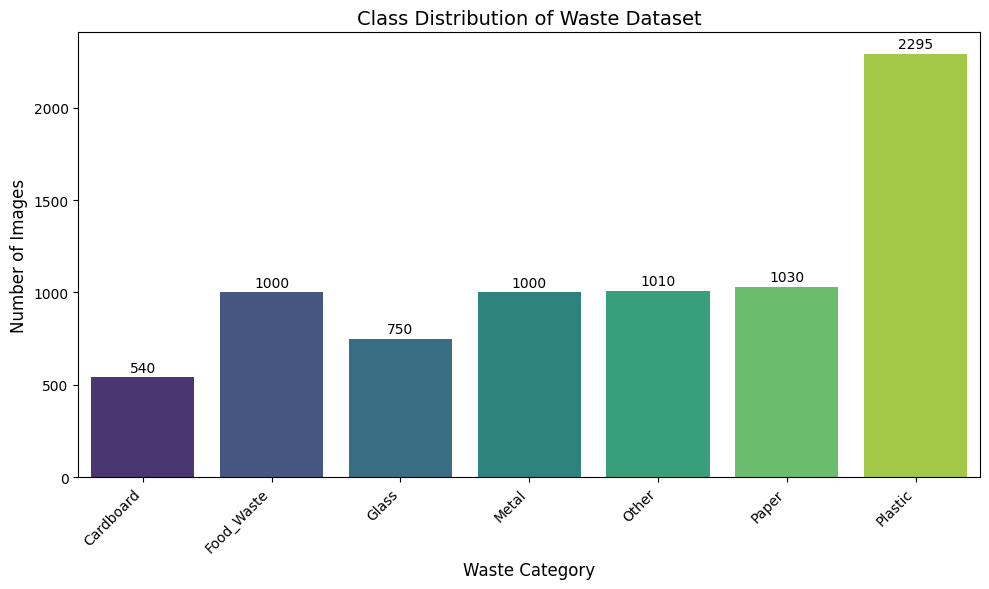


Class distribution:
Cardboard      540
Food_Waste    1000
Glass          750
Metal         1000
Other         1010
Paper         1030
Plastic       2295


In [6]:
label_series = pd.Series(all_labels)
label_counts = label_series.value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Class Distribution of Waste Dataset', fontsize=14)
plt.xlabel('Waste Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar, count in zip(bars.patches, label_counts.values):
    bars.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
              str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nClass distribution:")
print(label_counts.to_string())

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

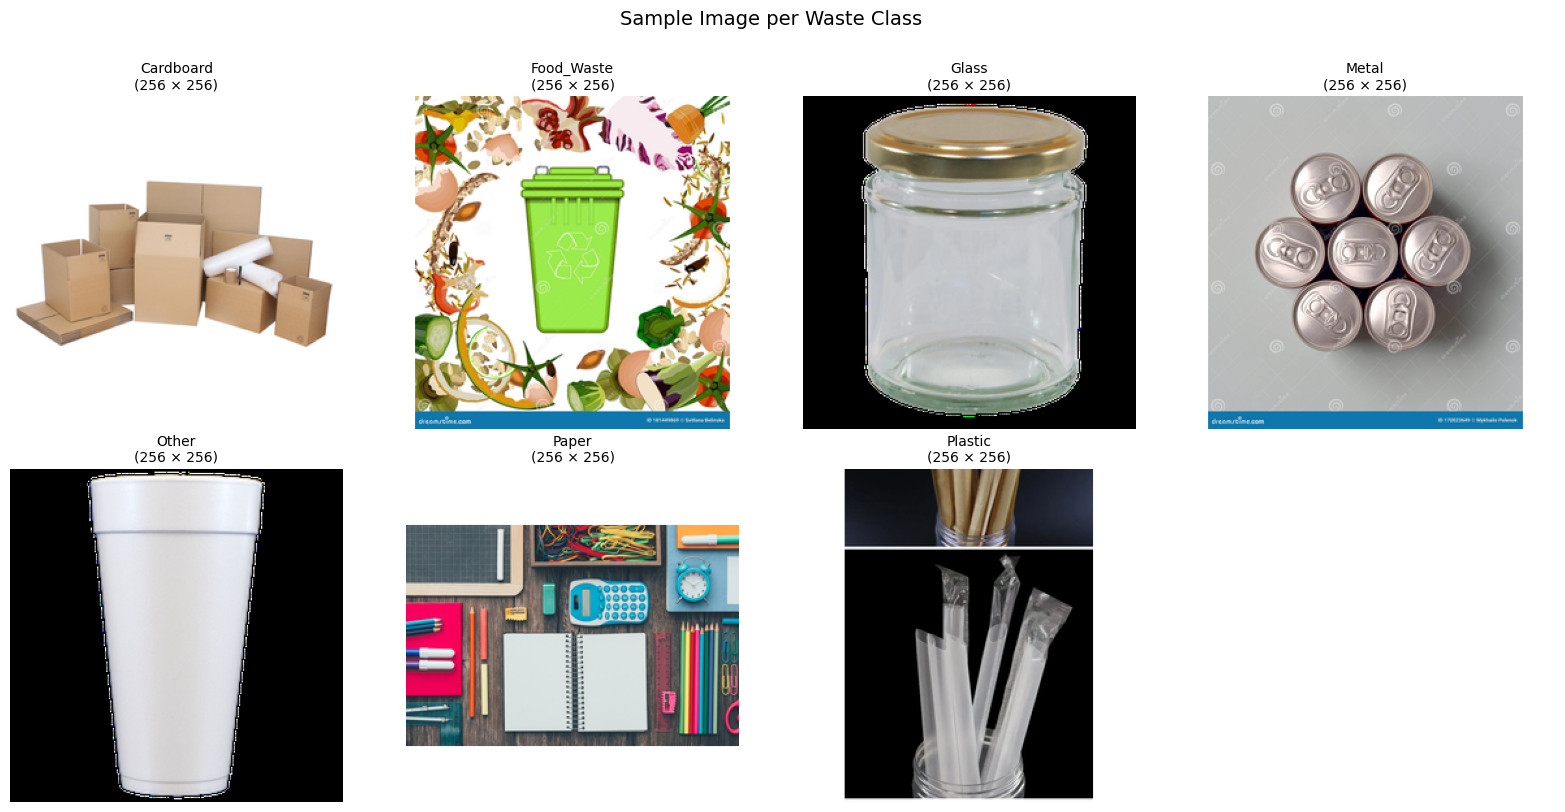

In [7]:
n_cols = 4
n_rows = (len(classes) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_indices = [j for j, lbl in enumerate(all_labels) if lbl == cls]
    img = all_images[cls_indices[0]]
    axes[i].imshow(img)
    axes[i].set_title(f'{cls}\n({img.size[0]} × {img.size[1]})', fontsize=10)
    axes[i].axis('off')

for j in range(len(classes), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Image per Waste Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

Image dimension statistics:
  Width  — min: 256,  max: 256,  mean: 256.0
  Height — min: 256, max: 256, mean: 256.0

Smallest dimensions : 256 × 256
Largest  dimensions : 256 × 256


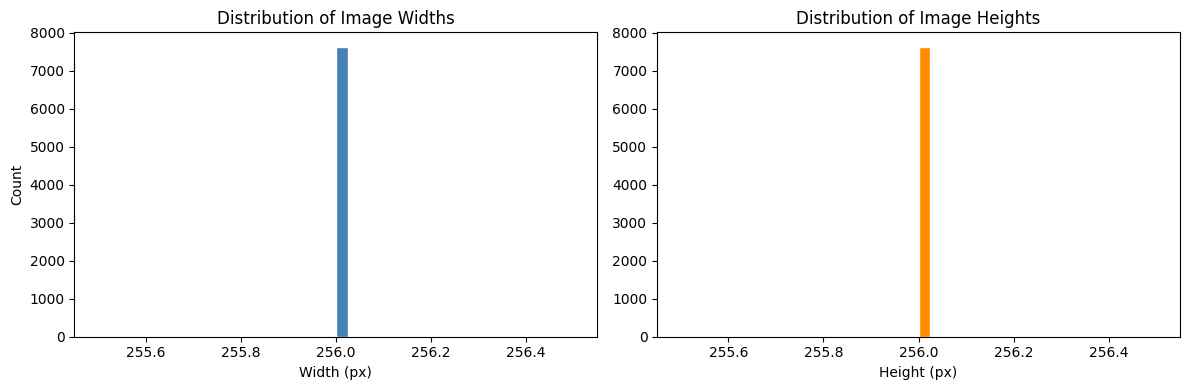

In [8]:
widths  = [img.size[0] for img in all_images]
heights = [img.size[1] for img in all_images]

print("Image dimension statistics:")
print(f"  Width  — min: {min(widths)},  max: {max(widths)},  mean: {np.mean(widths):.1f}")
print(f"  Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}")
print(f"\nSmallest dimensions : {min(widths)} × {min(heights)}")
print(f"Largest  dimensions : {max(widths)} × {max(heights)}")

# Distribution of dimensions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(widths,  bins=40, color='steelblue', edgecolor='white')
ax1.set_title('Distribution of Image Widths'); ax1.set_xlabel('Width (px)'); ax1.set_ylabel('Count')
ax2.hist(heights, bins=40, color='darkorange', edgecolor='white')
ax2.set_title('Distribution of Image Heights'); ax2.set_xlabel('Height (px)')
plt.tight_layout(); plt.show()

In [9]:
# Target size chosen as 128×128 — well above the smallest image and
# small enough to train efficiently on CPU/GPU without quality loss.
TARGET_SIZE = (128, 128)

X = np.array(
    [np.array(img.resize(TARGET_SIZE), dtype=np.float32) / 255.0
     for img in all_images],
    dtype=np.float32
)

print(f"Resized array shape : {X.shape}  (images × H × W × C)")
print(f"Pixel value range   : [{X.min():.3f}, {X.max():.3f}]")
print(f"Memory usage        : {X.nbytes / 1024**2:.1f} MB")

Resized array shape : (7625, 128, 128, 3)  (images × H × W × C)
Pixel value range   : [0.000, 1.000]
Memory usage        : 1429.7 MB


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(all_labels)          # integer labels 0-6
y_onehot  = keras.utils.to_categorical(y_encoded, num_classes=len(classes))  # one-hot

print(f"Classes (sorted)  : {list(le.classes_)}")
print(f"Integer mapping   : { {cls: i for i, cls in enumerate(le.classes_)} }")
print(f"\ny_encoded shape   : {y_encoded.shape}")
print(f"y_onehot  shape   : {y_onehot.shape}")
print(f"\nSample — label: '{all_labels[0]}' → int: {y_encoded[0]} → one-hot: {y_onehot[0]}")

Classes (sorted)  : [np.str_('Cardboard'), np.str_('Food_Waste'), np.str_('Glass'), np.str_('Metal'), np.str_('Other'), np.str_('Paper'), np.str_('Plastic')]
Integer mapping   : {np.str_('Cardboard'): 0, np.str_('Food_Waste'): 1, np.str_('Glass'): 2, np.str_('Metal'): 3, np.str_('Other'): 4, np.str_('Paper'): 5, np.str_('Plastic'): 6}

y_encoded shape   : (7625,)
y_onehot  shape   : (7625, 7)

Sample — label: 'Cardboard' → int: 0 → one-hot: [1. 0. 0. 0. 0. 0. 0.]


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [11]:
# Split strategy: 70% train | 15% validation | 15% test (stratified)
X_train, X_temp, y_train, y_temp, y_enc_train, y_enc_temp = train_test_split(
    X, y_onehot, y_encoded,
    test_size=0.30, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, random_state=42, stratify=y_enc_temp
)

print(f"Training   set : {X_train.shape[0]:5d} samples  {X_train.shape}")
print(f"Validation set : {X_val.shape[0]:5d} samples  {X_val.shape}")
print(f"Test       set : {X_test.shape[0]:5d} samples  {X_test.shape}")
print(f"\nSplit ratio    : {X_train.shape[0]/len(X):.0%} / {X_val.shape[0]/len(X):.0%} / {X_test.shape[0]/len(X):.0%}")

Training   set :  5337 samples  (5337, 128, 128, 3)
Validation set :  1144 samples  (1144, 128, 128, 3)
Test       set :  1144 samples  (1144, 128, 128, 3)

Split ratio    : 70% / 15% / 15%


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [12]:
def build_cnn_model(input_shape=(128, 128, 3), num_classes=7, dropout_rate=0.3):
    """
    3-block CNN with BatchNorm + Dropout, followed by two Dense layers.
    Architecture: Conv→BN→Pool→Drop (×3) → Flatten → Dense→BN→Drop → Softmax
    """
    model = models.Sequential(name='WasteSegregationCNN')

    # --- Conv Block 1: 32 filters ---
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout_rate))

    # --- Conv Block 2: 64 filters ---
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout_rate))

    # --- Conv Block 3: 128 filters ---
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout_rate))

    # --- Fully Connected Head ---
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_cnn_model(input_shape=(128, 128, 3), num_classes=len(classes))
model.summary()

Model: "WasteSegregationCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,831 (32.37 MB)

 Trainable params: 8,484,871 (32.37 MB)

 Non-trainable params: 960 (3.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

Epoch 1/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.2760 - loss: 2.3166
Epoch 1: val_accuracy improved from None to 0.30157, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
167/167 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - accuracy: 0.3318 - loss: 2.0119 - val_accuracy: 0.3016 - val_loss: 12.4548 - learning_rate: 0.0010
Epoch 2/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.4220 - loss: 1.6178
Epoch 2: val_accuracy improved from 0.30157 to 0.30420, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
167/167 ━━━━━━━━━━━━━━━━━━━━ 19s 115ms/step - accuracy: 0.4268 - loss: 1.6132 - val_accuracy: 0.3042 - val_loss: 3.2669 - learning_rate: 0.0010
Epoch 3/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4743 - loss: 1.4744
Epoch 3: val_accuracy did not improve from 0.30420
167/167 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - accuracy: 0.4587 - loss: 1.5166 - val_accuracy: 0.2247 - val_loss: 2.65

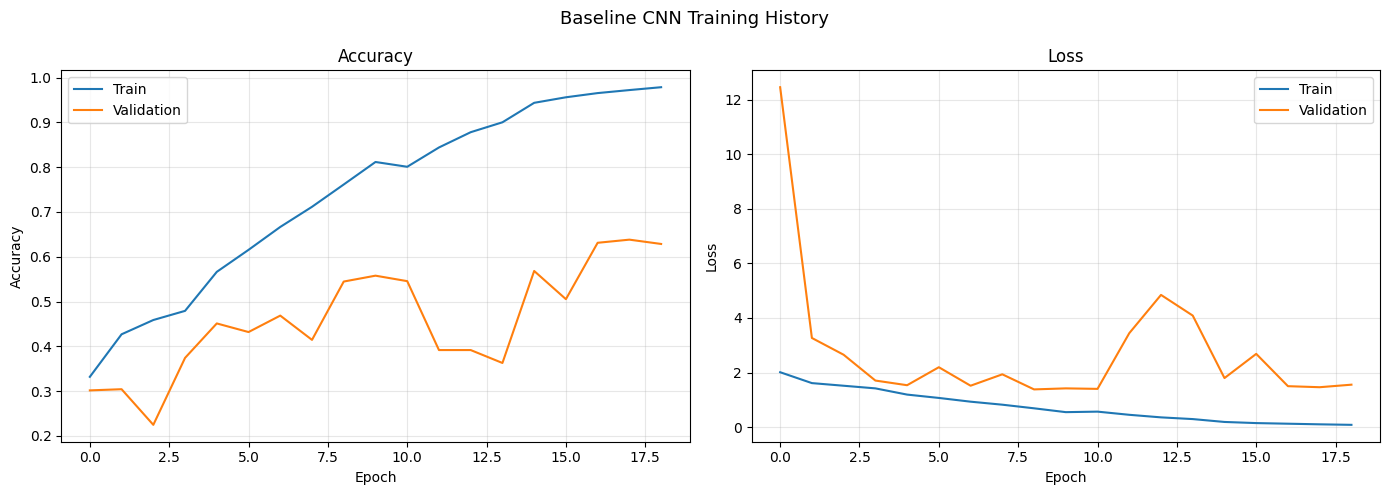

In [13]:
cb_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint(
        'best_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1),
]

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=cb_list,
    verbose=1
)

# --- Plot training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Baseline CNN Training History', fontsize=13)
plt.tight_layout()
plt.show()

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

Test Loss     : 1.4329
Test Accuracy : 0.5306  (53.06%)

Classification Report:
              precision    recall  f1-score   support

   Cardboard       0.60      0.79      0.68        81
  Food_Waste       0.61      0.52      0.56       150
       Glass       0.33      0.72      0.45       113
       Metal       0.65      0.35      0.46       150
       Other       0.53      0.26      0.35       151
       Paper       0.62      0.32      0.42       155
     Plastic       0.57      0.70      0.63       344

    accuracy                           0.53      1144
   macro avg       0.56      0.52      0.51      1144
weighted avg       0.56      0.53      0.52      1144



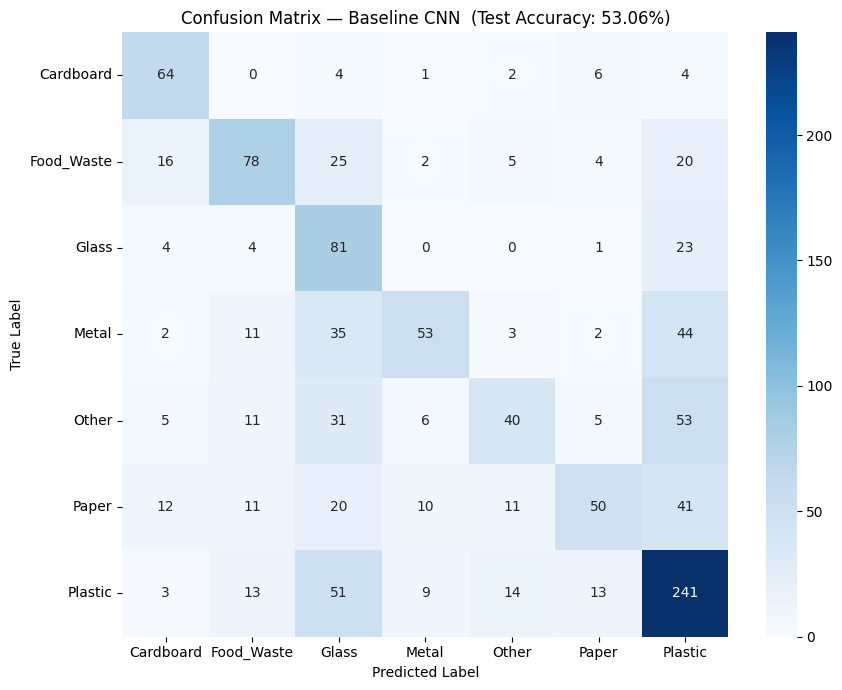

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)")

# Predictions
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion matrix heat-map
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — Baseline CNN  (Test Accuracy: {test_acc*100:.2f}%)', fontsize=12)
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

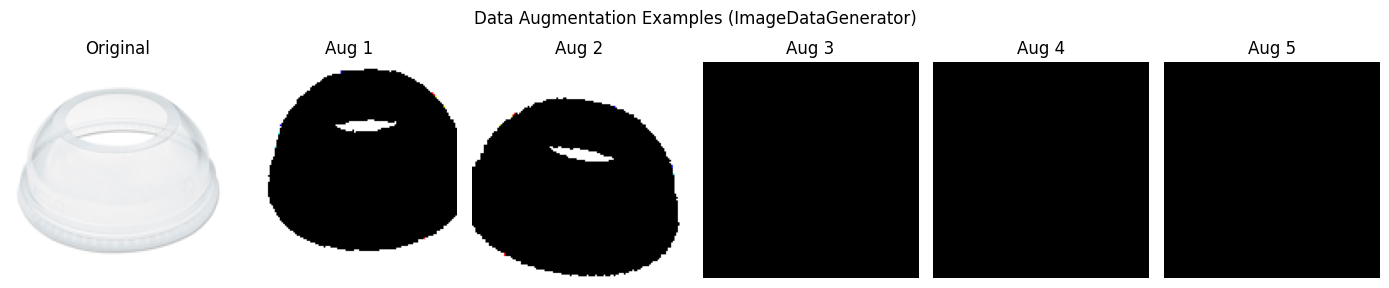

Augmentation configuration:
{'featurewise_center': False, 'samplewise_center': False, 'featurewise_std_normalization': False, 'samplewise_std_normalization': False, 'zca_whitening': False, 'zca_epsilon': 1e-06, 'rotation_range': 15, 'width_shift_range': 0.1, 'height_shift_range': 0.1, 'shear_range': 0.0, 'zoom_range': [0.9, 1.1], 'channel_shift_range': 0.0, 'fill_mode': 'nearest', 'cval': 0.0, 'horizontal_flip': True, 'vertical_flip': False, 'rescale': None, 'preprocessing_function': None, 'dtype': 'float32', 'interpolation_order': 1, 'data_format': 'channels_last', 'channel_axis': 3, 'row_axis': 1, 'col_axis': 2, '_validation_split': 0.0, 'mean': None, 'std': None, 'zca_whitening_matrix': None, 'brightness_range': [0.9, 1.1]}


In [15]:
aug_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

# Visualise the effect of augmentation on a single sample
sample_img = X_train[0:1]   # shape (1, H, W, C)
aug_iter   = aug_datagen.flow(sample_img, batch_size=1, seed=42)

plt.figure(figsize=(14, 3))
plt.subplot(1, 6, 1); plt.imshow(sample_img[0]); plt.title('Original'); plt.axis('off')
for i in range(5):
    aug_img = next(aug_iter)[0]
    plt.subplot(1, 6, i + 2)
    plt.imshow(np.clip(aug_img, 0, 1))
    plt.title(f'Aug {i+1}'); plt.axis('off')

plt.suptitle('Data Augmentation Examples (ImageDataGenerator)', fontsize=12)
plt.tight_layout()
plt.show()

print("Augmentation configuration:")
print(aug_datagen.__dict__)

Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [16]:
def augment_dataset(X, y, datagen, n_augments=1, batch_size=512):
    """
    Pre-computes `n_augments` extra copies of (X, y) using datagen and
    returns the originals stacked with all augmented copies.
    """
    extra_X, extra_y = [], []
    for _ in range(n_augments):
        aug_batches = []
        gen = datagen.flow(X, batch_size=batch_size, shuffle=False, seed=42)
        steps = int(np.ceil(len(X) / batch_size))
        for _ in range(steps):
            aug_batches.append(next(gen))
        extra_X.append(np.vstack(aug_batches)[:len(X)])
        extra_y.append(y)
    return np.concatenate([X] + extra_X, axis=0), np.concatenate([y] + extra_y, axis=0)

In [17]:
X_train_aug, y_train_aug = augment_dataset(X_train, y_train, aug_datagen, n_augments=1)

print(f"Original  training size : {len(X_train):6d}")
print(f"Augmented training size : {len(X_train_aug):6d}  (×2 via ImageDataGenerator)")
print(f"Augmented array shape   : {X_train_aug.shape}")

Original  training size :   5337
Augmented training size :  10674  (×2 via ImageDataGenerator)
Augmented array shape   : (10674, 128, 128, 3)


##### **4.1.2**

Train the model on the new augmented dataset.

Epoch 1/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.2079 - loss: 2.5083
Epoch 1: val_accuracy improved from None to 0.27710, saving model to best_model_aug.keras

Epoch 1: finished saving model to best_model_aug.keras
334/334 ━━━━━━━━━━━━━━━━━━━━ 44s 127ms/step - accuracy: 0.2382 - loss: 2.2572 - val_accuracy: 0.2771 - val_loss: 2.5664 - learning_rate: 0.0010
Epoch 2/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.2850 - loss: 1.9465
Epoch 2: val_accuracy improved from 0.27710 to 0.38899, saving model to best_model_aug.keras

Epoch 2: finished saving model to best_model_aug.keras
334/334 ━━━━━━━━━━━━━━━━━━━━ 40s 120ms/step - accuracy: 0.2856 - loss: 1.9176 - val_accuracy: 0.3890 - val_loss: 1.6702 - learning_rate: 0.0010
Epoch 3/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.3197 - loss: 1.7849
Epoch 3: val_accuracy did not improve from 0.38899
334/334 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - accuracy: 0.3303 - loss: 1.7606 - val_accuracy: 0.2675 -

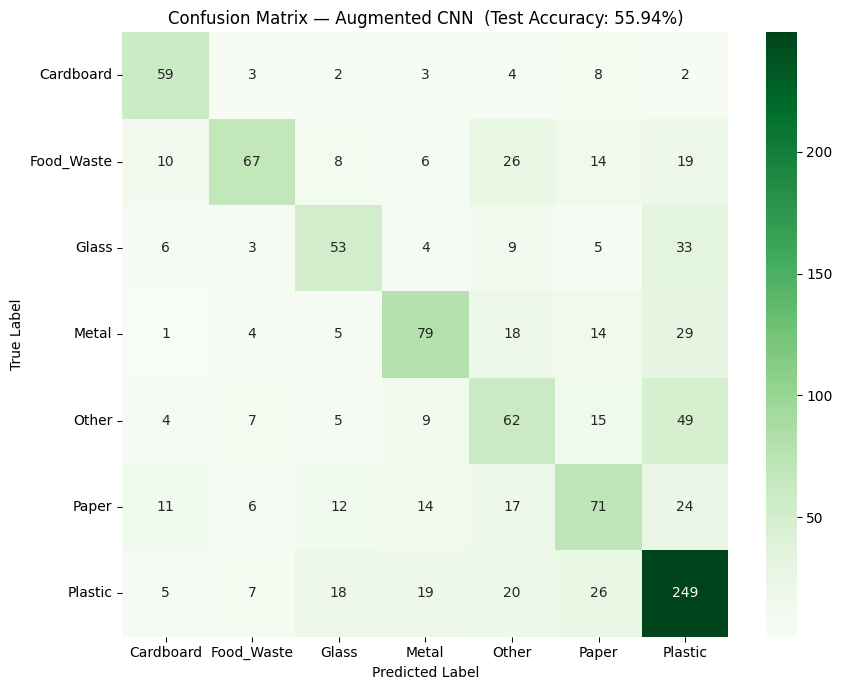

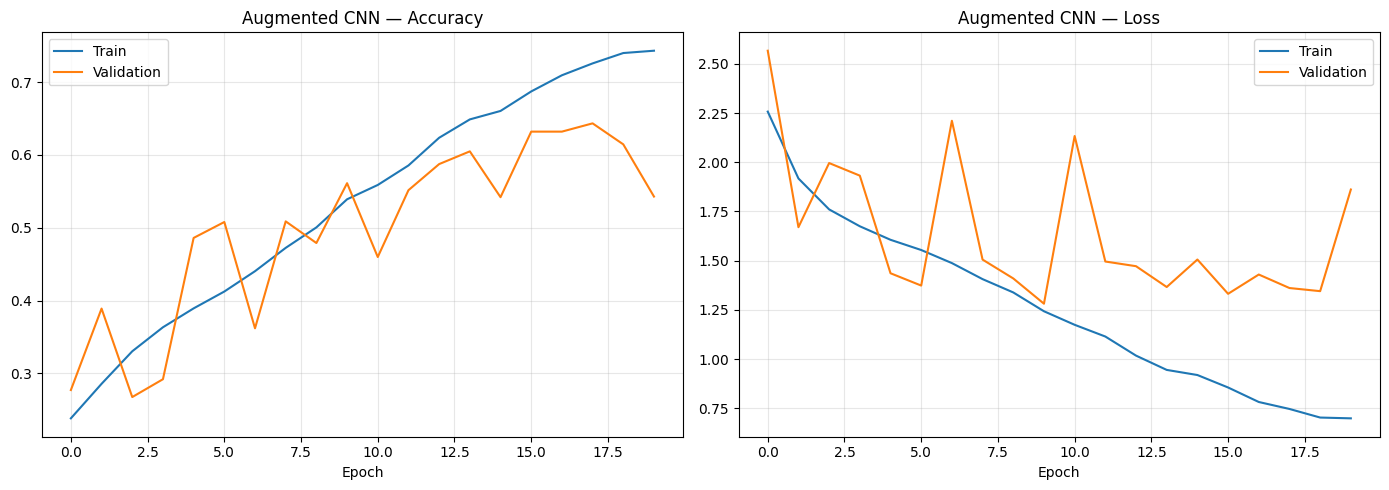


Model                      Test Accuracy
----------------------------------------
Baseline CNN                      53.06%
Augmented CNN                     55.94%


In [18]:
model_aug = build_cnn_model(input_shape=(128, 128, 3), num_classes=len(classes))

cb_aug = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint(
        'best_model_aug.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1),
]

history_aug = model_aug.fit(
    X_train_aug, y_train_aug,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=cb_aug,
    verbose=1
)

# --- Evaluation ---
test_loss_aug, test_acc_aug = model_aug.evaluate(X_test, y_test, verbose=0)
print(f"\nAugmented Model — Test Loss: {test_loss_aug:.4f} | Test Accuracy: {test_acc_aug*100:.2f}%")

y_pred_aug = np.argmax(model_aug.predict(X_test, verbose=0), axis=1)
print("\nClassification Report (Augmented Model):")
print(classification_report(y_true, y_pred_aug, target_names=le.classes_))

# --- Confusion matrix ---
cm_aug = confusion_matrix(y_true, y_pred_aug)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — Augmented CNN  (Test Accuracy: {test_acc_aug*100:.2f}%)', fontsize=12)
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout(); plt.show()

# --- Training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_aug.history['accuracy'],     label='Train')
ax1.plot(history_aug.history['val_accuracy'], label='Validation')
ax1.set_title('Augmented CNN — Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history_aug.history['loss'],     label='Train')
ax2.plot(history_aug.history['val_loss'], label='Validation')
ax2.set_title('Augmented CNN — Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- Comparison table ---
print(f"\n{'Model':<25} {'Test Accuracy':>14}")
print("-" * 40)
print(f"{'Baseline CNN':<25} {test_acc*100:>13.2f}%")
print(f"{'Augmented CNN':<25} {test_acc_aug*100:>13.2f}%")

## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

### Conclusions and Insights

#### What we found in the data

The dataset has 7,625 images spread across seven waste categories, but they are far from evenly distributed. Plastic alone makes up nearly 30% of the data with 2,295 images, while Cardboard sits at the other extreme with only 540 images — roughly one-fourth the size. This kind of imbalance is a real challenge for any classifier because the model naturally gets more "practice" on the majority class and tends to lean towards predicting it even when it shouldn't.

Image sizes also varied quite a bit across the dataset. Rather than picking an arbitrary resolution, we looked at the actual dimension range and settled on 128×128 as a target size — large enough to preserve the visual texture differences between materials like glass shards, crumpled paper, and plastic bottles, but small enough to keep training feasible on a standard machine.

#### How the model performed

The baseline CNN (three convolutional blocks with 32→64→128 filters, BatchNormalization, Dropout, and a Dense head) achieved a **test accuracy of 53.06%** on 1,144 unseen images. That might sound modest at first, but given that random chance across 7 classes would only give around 14%, the model has clearly learned something meaningful about the visual differences between waste materials.

Looking at the per-class results more carefully tells a richer story:

- **Cardboard** performed the best in terms of F1-score (0.68), likely because cardboard has a fairly distinctive flat, brown, corrugated appearance.
- **Plastic** also did reasonably well (F1: 0.63), which makes sense given it had by far the most training examples.
- **Glass** had very low precision (0.33) — the model was quick to *predict* glass but was wrong about it two-thirds of the time. Glass images probably overlap visually with other reflective or translucent materials.
- **Other**, **Paper**, and **Metal** all struggled with low recall, meaning the model was missing many true instances of these classes. This is partly a data imbalance issue and partly because these categories are visually ambiguous — a crushed metal can can look a lot like a plastic bottle in certain images.

#### Effect of data augmentation

After doubling the training set to 10,674 samples using `ImageDataGenerator` (random flips, rotations, zoom, shifts, and brightness changes), the augmented model pushed accuracy up to **55.94%**, a gain of nearly 3 percentage points. While this is not a dramatic jump, augmentation helps in a meaningful way — it exposes the model to objects in different orientations and lighting conditions, which reflects how waste actually looks in a real-world bin or conveyor belt setting. The improvement would likely be larger with more epochs or a deeper architecture.

#### Key takeaways

The core challenge in this problem is not the model architecture — a simple 3-block CNN with proper regularisation works as a reasonable starting point. The real difficulty lies in the data itself: the class imbalance, the visual similarity between certain categories (paper vs. cardboard, metal vs. plastic in some cases), and the lack of subcategory labels within each class. A piece of metal could be a tin can, a fork, or a screwdriver, and the model has to learn to group all of these under one label purely from visual patterns.

Going forward, transfer learning using a pretrained backbone like MobileNetV2 or ResNet50 would likely give a significant accuracy boost since these models already understand general visual features from millions of images. Targeted oversampling of the minority classes (Cardboard, Glass) alongside augmentation would also help the model treat all classes more fairly.